In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
import h3
import branca.colormap as cm

In [3]:
orders_df = pd.read_csv("data_orders.csv")
orders_df.head()


,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [4]:
orders_df['order_datetime'] = pd.to_datetime(orders_df['order_datetime'], format='%H:%M:%S')


In [5]:
orders_df.shape

(10716, 8)

In [6]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10716 entries, 0 to 10715
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_datetime                 10716 non-null  datetime64[us]
 1   origin_longitude               10716 non-null  float64       
 2   origin_latitude                10716 non-null  float64       
 3   m_order_eta                    2814 non-null   float64       
 4   order_gk                       10716 non-null  int64         
 5   order_status_key               10716 non-null  int64         
 6   is_driver_assigned_key         10716 non-null  int64         
 7   cancellations_time_in_seconds  7307 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(3)
memory usage: 669.9 KB


In [7]:
orders_df['is_driver_assigned_key']=orders_df['is_driver_assigned_key'].replace(
    {0:"No",
     1:"Yes"}
)


In [8]:
orders_df['order_status_key']=orders_df['order_status_key'].replace(
    {4:"Client Cancelled",
     9:"System Rejected"}
)

## Build up distribution of orders according to reasons for failure: cancellations before and after driver assignment, and reasons for order rejection. 
#### Analyse the resulting plot. Which category has the highest number of orders?

In [9]:
pd.crosstab(orders_df['order_status_key'], orders_df['is_driver_assigned_key'])

is_driver_assigned_key,No,Yes
order_status_key,,
Client Cancelled,4496,2811
System Rejected,3406,3


In [10]:
cancelled_before_assignment = orders_df.loc[(orders_df['is_driver_assigned_key'] == 'No')&(orders_df['order_status_key'] == 'Client Cancelled')]
cancelled_after_assignment = orders_df.loc[(orders_df['is_driver_assigned_key']=='Yes') &(orders_df['order_status_key'] == 'Client Cancelled')]
rejected_by_system_before_assigment = orders_df.loc[(orders_df['is_driver_assigned_key']=='No') & (orders_df['order_status_key']=='System Rejected')]
rejected_by_system_after_assigment = orders_df.loc[(orders_df['is_driver_assigned_key']=='Yes') & (orders_df['order_status_key']=='System Rejected')]

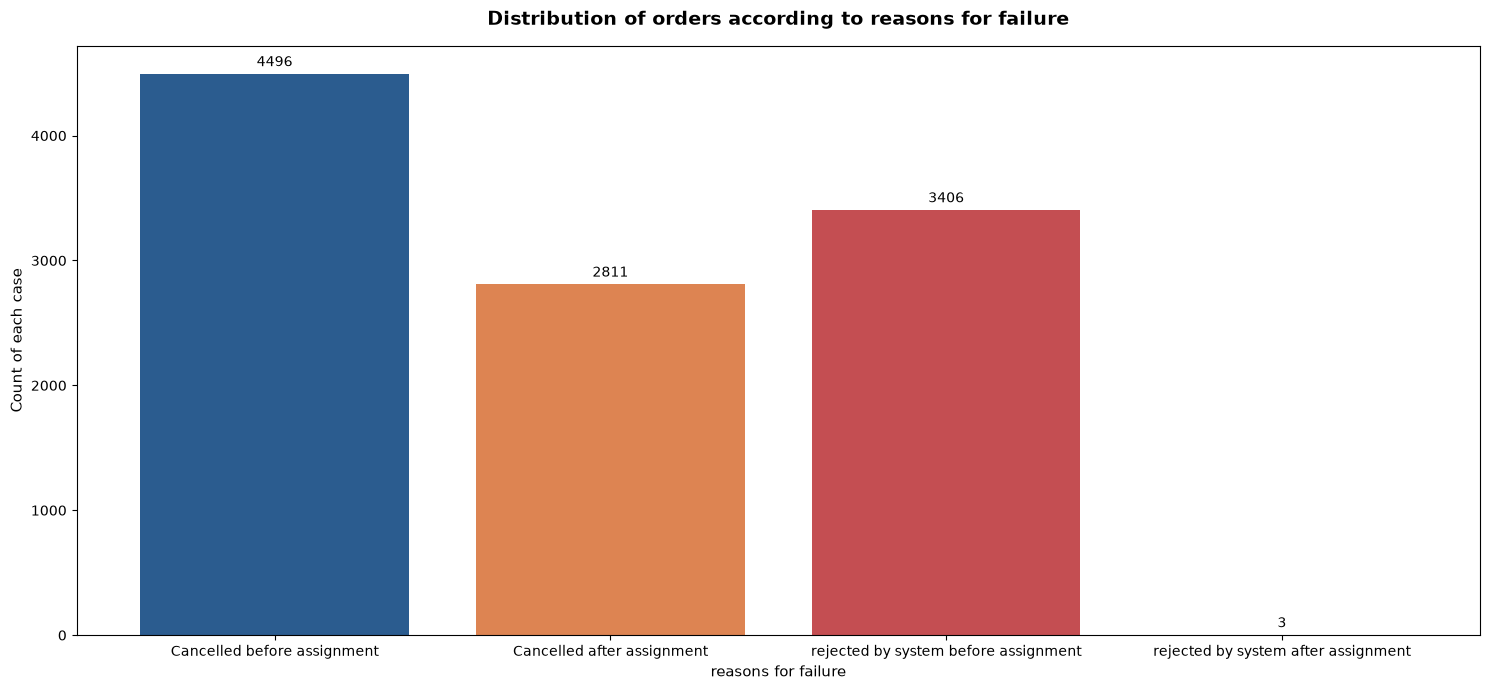

In [12]:
reasons_of_failures = pd.Series({
    "Cancelled before assignment" : len(cancelled_before_assignment),
    "Cancelled after assignment"  : len(cancelled_after_assignment),
    "rejected by system before assignment" : len(rejected_by_system_before_assigment),
    "rejected by system after assignment" : len(rejected_by_system_after_assigment)
    }
)


plt.figure(figsize=(15,7))
bars = plt.bar(x=reasons_of_failures.index, height=reasons_of_failures.values, color=["#2b5c8f", "#DD8452", "#C44E52"])

plt.bar_label(bars, padding=3)
plt.title("Distribution of orders according to reasons for failure",fontsize=14, pad=15, fontweight='bold')
plt.xlabel("reasons for failure", fontsize=11)
plt.ylabel("Count of each case", fontsize=11)
plt.tight_layout()
plt.savefig("failure_reasons.png", dpi=150, bbox_inches='tight')
plt.show()

## Plot the distribution of failed orders by hours
#### Is there a trend that certain hours have an abnormally high proportion of one category or another? What hours are the biggest fails? How can this be explained?


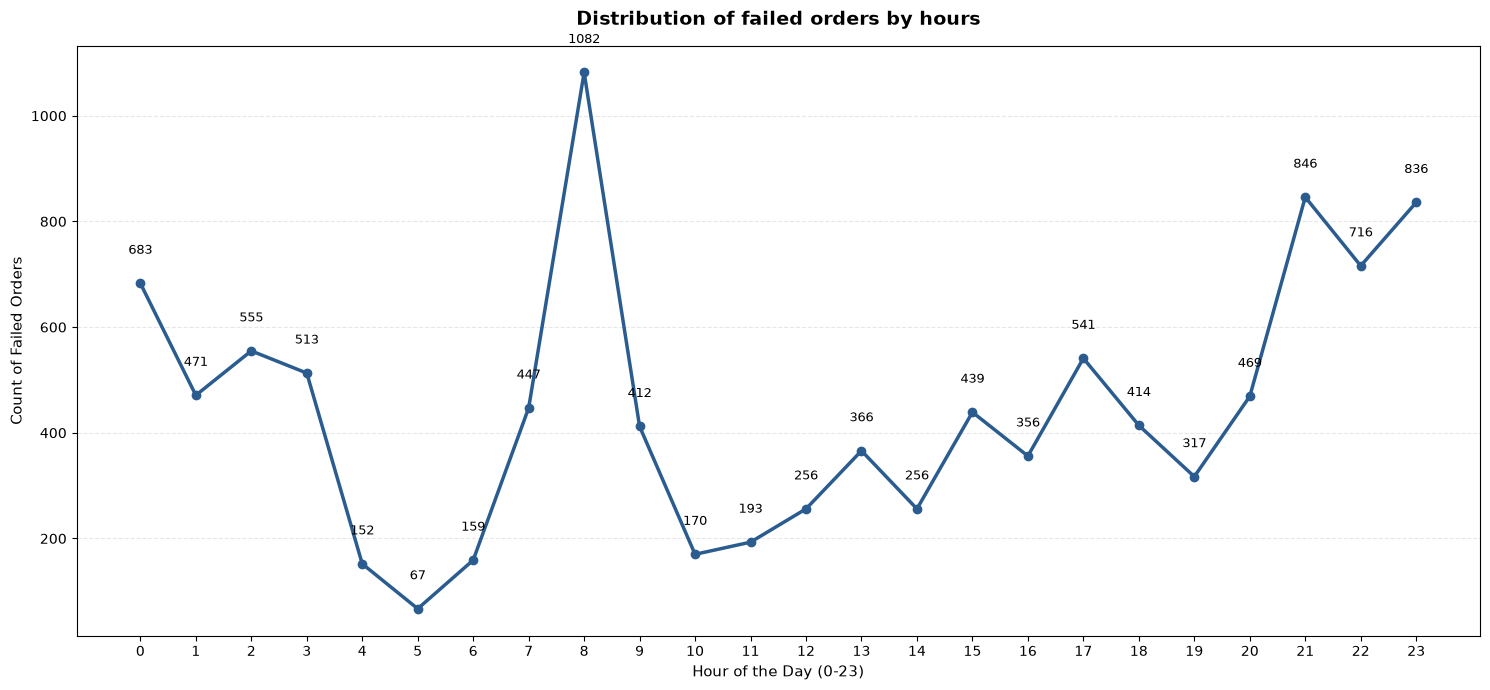

In [14]:

df_grouped_by_hour = orders_df.groupby(orders_df['order_datetime'].dt.hour).size()
plt.figure(figsize=(15,7))
plt.plot(df_grouped_by_hour.index, df_grouped_by_hour.values, color="#2b5c8f", linewidth=2.5, marker='o')
for x, y in zip(df_grouped_by_hour.index, df_grouped_by_hour.values):
    plt.text(x, y + 50, str(y), ha='center', va='bottom', fontsize=9)

plt.xticks(range(0,24))
plt.title("Distribution of failed orders by hours",fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Hour of the Day (0-23)", fontsize=11)
plt.ylabel("Count of Failed Orders", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("hourly_failures1.png", dpi=150, bbox_inches='tight')
plt.show()

hour  is_driver_assigned_key  order_status_key
0     No                      Client Cancelled    298
                              System Rejected     263
      Yes                     Client Cancelled    120
                              System Rejected       2
1     No                      Client Cancelled    219
                                                 ... 
22    No                      System Rejected     241
      Yes                     Client Cancelled    149
23    No                      Client Cancelled    378
                              System Rejected     302
      Yes                     Client Cancelled    156
Length: 74, dtype: int64


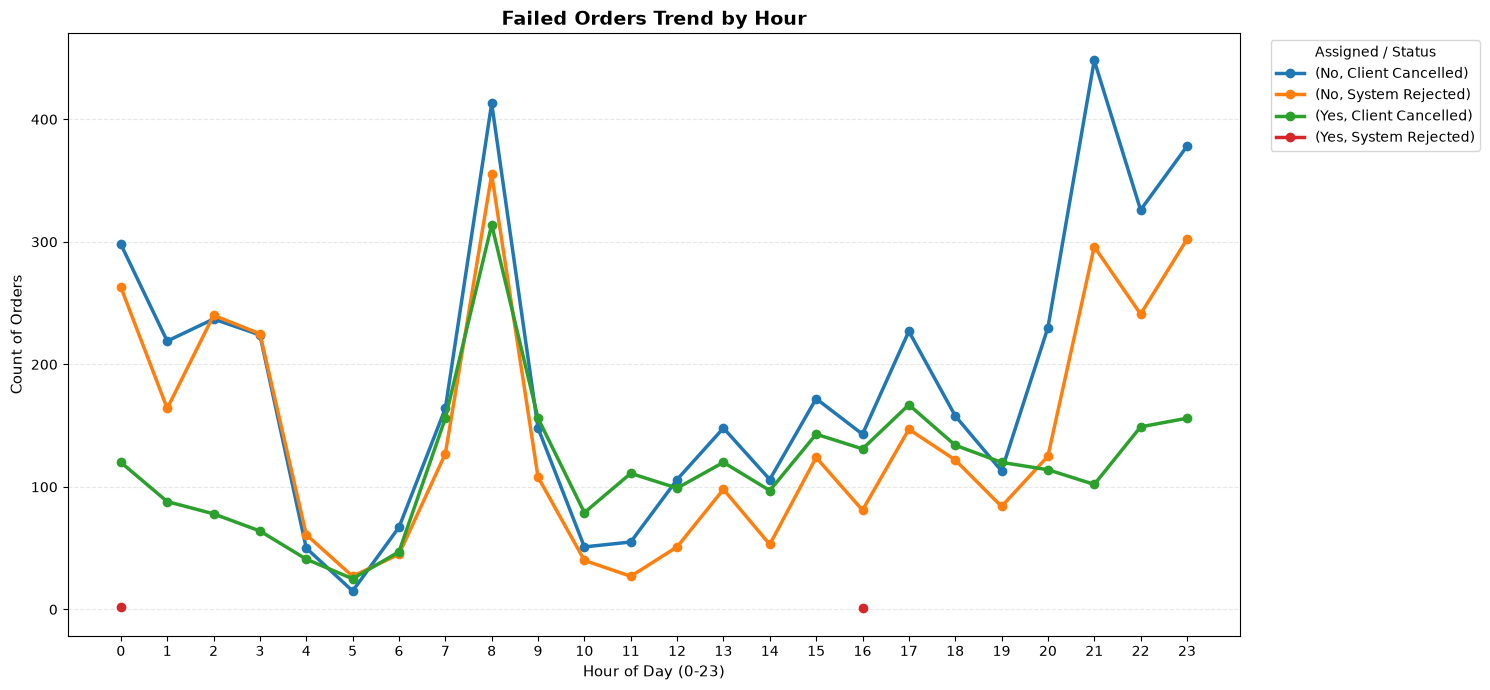

In [15]:
orders_df['hour'] =orders_df['order_datetime'].dt.hour
df_grouped_by_hour_and_catogory = orders_df.groupby(['hour', 'is_driver_assigned_key','order_status_key']).size()
print(df_grouped_by_hour_and_catogory)

df_unstacked = df_grouped_by_hour_and_catogory.unstack(level=["is_driver_assigned_key", "order_status_key"])

ax = df_unstacked.plot(figsize=(15, 7), marker="o", linewidth=2.5)

plt.xticks(range(0, 24))
plt.title("Failed Orders Trend by Hour", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day (0-23)", fontsize=11)
plt.ylabel("Count of Orders", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Assigned / Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("hourly_failures2.png", dpi=150, bbox_inches='tight')
plt.show()

### Plot the average time to cancellation with and without driver, by the hour.
#### If there are any outliers in the data, it would be better to remove them. Can we draw any conclusions from this plot?

hour  is_driver_assigned_key
0     No                         89.0
      Yes                       200.5
1     No                         84.0
      Yes                       151.0
2     No                         87.0
      Yes                       207.0
3     No                         83.5
      Yes                       115.5
4     No                         65.5
      Yes                       132.0
5     No                        112.0
      Yes                        99.0
6     No                         85.0
      Yes                        89.0
7     No                         95.5
      Yes                       120.0
8     No                         95.0
      Yes                       111.5
9     No                         92.5
      Yes                       125.5
10    No                         61.0
      Yes                       108.0
11    No                         49.0
      Yes                       171.0
12    No                         71.5
      Yes            

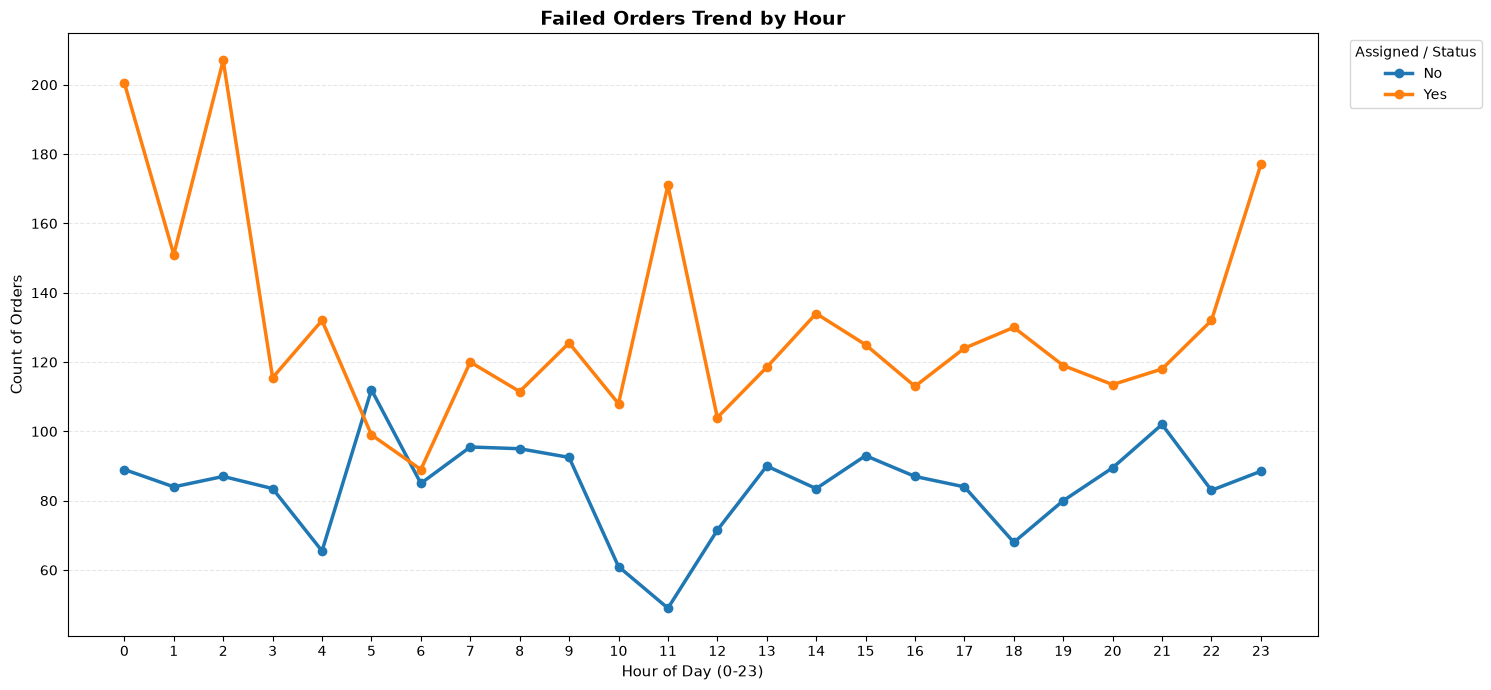

In [16]:
df_grouped_by_hour_and_driver_key = orders_df.groupby(['hour','is_driver_assigned_key'])['cancellations_time_in_seconds'].median()
print(df_grouped_by_hour_and_driver_key)
df_grouped_by_hour_and_driver_key_unstacked = df_grouped_by_hour_and_driver_key.unstack(level=['is_driver_assigned_key'])
ax = df_grouped_by_hour_and_driver_key_unstacked.plot(figsize=(15, 7), marker="o", linewidth=2.5)

plt.xticks(range(0, 24))
plt.title("Failed Orders Trend by Hour", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day (0-23)", fontsize=11)
plt.ylabel("Count of Orders", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Assigned / Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("cancellation_time.png", dpi=150, bbox_inches='tight')
plt.show()

### Plot the distribution of average ETA by hours.
#### How can this plot be explained?

hour
0     298.0
1     297.5
2     298.0
3     328.0
4     238.0
5     358.0
6     359.0
7     584.5
8     658.0
9     478.5
10    348.0
11    358.0
12    417.0
13    416.0
14    358.0
15    419.0
16    387.0
17    479.0
18    415.5
19    298.0
20    266.5
21    298.0
22    298.0
23    299.0
Name: m_order_eta, dtype: float64


C:\Users\Sara\AppData\Local\Temp\ipykernel_19052\2455205037.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Assigned / Status", bbox_to_anchor=(1.02, 1), loc="upper left")


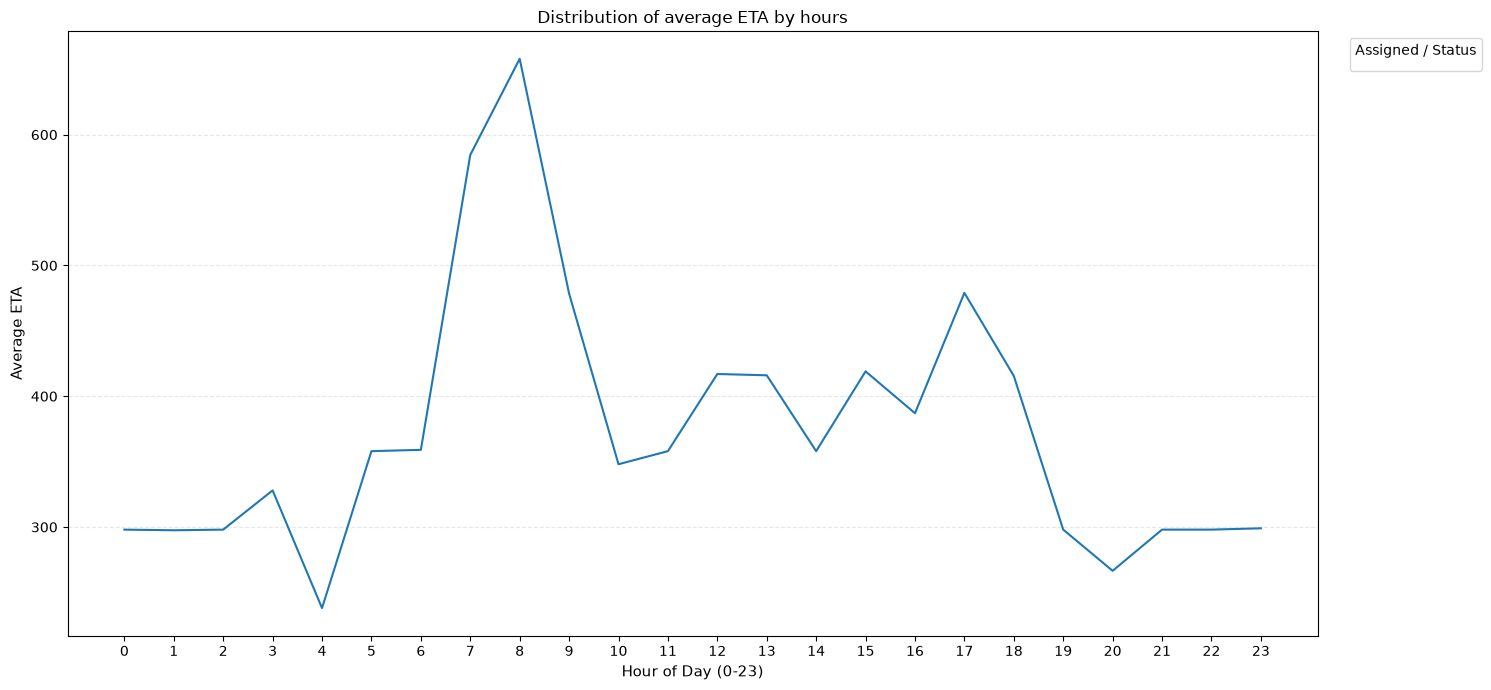

In [17]:
df_average_ETA = orders_df.groupby('hour')['m_order_eta'].median()
print(df_average_ETA)

plt.figure(figsize=(15,7))
plt.plot(df_average_ETA.index, df_average_ETA.values)
plt.xticks(range(0,24))
plt.title('Distribution of average ETA by hours')
plt.xlabel("Hour of Day (0-23)", fontsize=11)
plt.ylabel("Average ETA", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Assigned / Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("eta_by_hour.png", dpi=150, bbox_inches='tight')

plt.show()

### BONUS Hexagons. 
#### Using the h3 and folium packages, calculate how many sizes 8 hexes contain 80% of all orders from the original data sets and visualise the hexes, colouring them by the number of fails on the map.

In [26]:
vec_latlng_to_cell = np.vectorize(h3.latlng_to_cell)

orders_df['hex_id'] = vec_latlng_to_cell(orders_df['origin_latitude'], orders_df['origin_longitude'], res=8)
orders_df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds,hour,hex_id
0,1900-01-01 18:08:07,-0.978916,51.456173,60.0,3000583041974,Client Cancelled,Yes,198.0,18,88195d2b03fffff
1,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,Client Cancelled,No,128.0,20,88195d2b19fffff
2,1900-01-01 12:07:50,-0.969520,51.455544,477.0,3000582891479,Client Cancelled,Yes,46.0,12,88195d2b1dfffff
3,1900-01-01 13:50:20,-1.054671,51.460544,658.0,3000582941169,Client Cancelled,Yes,62.0,13,88195d7497fffff
4,1900-01-01 21:24:45,-0.967605,51.458236,NaN,3000583140877,System Rejected,No,NaN,21,88195d2b1dfffff


In [37]:
# 1. Convert GPS coordinates to H3 Hex IDs
vec_latlng_to_cell = np.vectorize(h3.latlng_to_cell)
orders_df['hex_id'] = vec_latlng_to_cell(orders_df['origin_latitude'], orders_df['origin_longitude'], res=8)

# 2. Group by hex_id, count orders, sort DESCENDING (biggest hex first)
df_grouped_by_hex_id = (
    orders_df.groupby('hex_id')['order_gk']
    .count()
    .sort_values(ascending=False)
    .reset_index(name='order_count')
)

# 3. Calculate running total percentage (Cumulative Percentage)
df_grouped_by_hex_id['Cum_Percentage'] = (
    df_grouped_by_hex_id['order_count'].cumsum() / df_grouped_by_hex_id['order_count'].sum()
) * 100

# 4. Count how many of the BIGGEST hexes it takes to reach 80% of orders
n_hexes_80 = (df_grouped_by_hex_id['Cum_Percentage'] < 80).sum() + 1
print(f"Number of hexes covering 80% of orders: {n_hexes_80}")

# 5. Those are your top hexes (busiest, not "remaining 20%")
top_hexes = df_grouped_by_hex_id.head(n_hexes_80)
print("\nBusiest hexes making up 80% of all orders:")
print(top_hexes)



Number of hexes covering 80% of orders: 24

Busiest hexes making up 80% of all orders:
             hex_id  order_count  Cum_Percentage
0   88195d2b1dfffff         1497       13.969765
1   88195d2b1bfffff          870       22.088466
2   88195d2b15fffff          774       29.311310
3   88195d2b11fffff          707       35.908921
4   88195d2b19fffff          667       42.133259
5   88195d284dfffff          653       48.226950
6   88195d2a27fffff          414       52.090332
7   88195d2b0bfffff          372       55.561777
8   88195d2a25fffff          362       58.939903
9   88195d2b13fffff          346       62.168720
10  88195d2b03fffff          257       64.567003
11  88195d2b17fffff          210       66.526689
12  88195d2b39fffff          184       68.243748
13  88195d2861fffff          182       69.942143
14  88195d2a21fffff          156       71.397910
15  88195d2b3dfffff          153       72.825681
16  88195d2b31fffff          143       74.160134
17  88195d2869fffff          12

In [38]:
colormap = cm.LinearColormap(
    colors=['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15'],
    vmin=df_grouped_by_hex_id['order_count'].min(),
    vmax=df_grouped_by_hex_id['order_count'].max(),
    caption='Number of Orders per Hexagon'
)

tiles_url = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}'
attr = 'Tiles &copy; Esri &mdash; Source: Esri, DeLorme, NAVTEQ, USGS, Intermap, iPC, NRCAN, Esri Japan, METI, Esri China (Hong Kong), Esri (Thailand), TomTom, 2012'
m = folium.Map(
    location=[orders_df['origin_latitude'].mean(), orders_df['origin_longitude'].mean()],
    zoom_start=12,
    tiles=tiles_url,
    attr=attr
)

for _, row in df_grouped_by_hex_id.iterrows():
    hex_id = row['hex_id']
    order_count = row['order_count']
    boundary = h3.cell_to_boundary(hex_id)
    
    folium.Polygon(
        locations=boundary,
        color=colormap(order_count),
        fill=True,
        fill_color=colormap(order_count),
        fill_opacity=0.7,
        weight=1,
        popup=f"Hex: {hex_id}<br>Orders: {order_count}"
    ).add_to(m)

colormap.add_to(m)

m.save("map.html")
m